# Game of Life Mosaics - Quick Start

This notebook demonstrates how to create your first Game of Life mosaic in just a few lines of code.

## What we'll do:
1. Import the library
2. Create a mosaic generator
3. Generate a mosaic from an image
4. Display and save the result

## Setup

First, import the required libraries:

In [1]:
# Import libraries
from pathlib import Path

# The repository root, wherever Jupyter was started from
REPO = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "pyproject.toml").exists())

import matplotlib.pyplot as plt
from PIL import Image

# Import gol_mosaics (installed with: pip install -e .)
from gol_mosaics import MosaicGenerator, ImageProcessor

%load_ext autoreload
%autoreload 2

## Step 1: Load and prepare the image

We'll use a portrait of the inventor of the Game of Life, **John Horton
Conway**, whose background has already been removed (it is transparent).

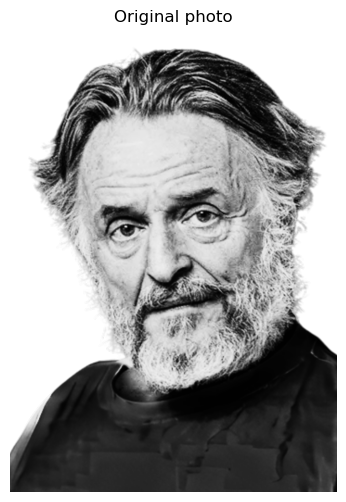

In [2]:
# A portrait with its background already removed (transparent)
input_path = REPO / 'input/images/john.png'
original = Image.open(input_path)

plt.figure(figsize=(6, 6))
plt.imshow(original)
plt.title('Original photo')
plt.axis('off')
plt.show()

The mosaic works from a **greyscale image with the background removed and the
contrast boosted**. `ImageProcessor.load_image` does all of that in one step
(background removal when needed + greyscale + an S-curve contrast boost), and
`generate_from_image` calls it for you. To start from a photo that still has
its background, and to see each stage, open
[`03_preprocessing.ipynb`](03_preprocessing.ipynb) (it needs the optional
`rembg` package: `pip install gol-mosaics[bg-removal]`).

_NOTE_: you can use your own image — a portrait with a clear subject works best.
If it already has a transparent background it is used as-is.

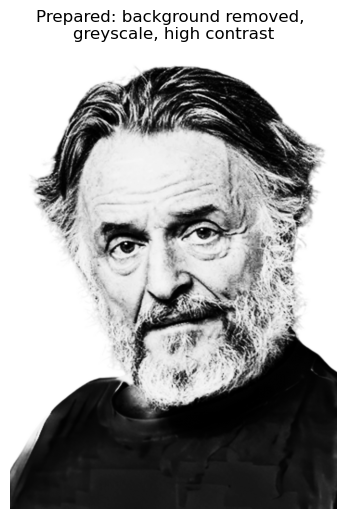

In [3]:
# One call: automatic background removal + greyscale + contrast boost
prepped = ImageProcessor.load_image(input_path)

plt.figure(figsize=(6, 6))
plt.imshow(prepped, cmap='gray')
plt.title('Prepared: background removed, \ngreyscale, high contrast')
plt.axis('off')
plt.show()

## Step 2: Create Mosaic Generator

Create a generator with default (randomised) settings:

In [4]:
# Create generator with default randomised settings
# This will use UGent colours (blue and yellow)

generator = MosaicGenerator()

print(f"Generator created: {generator}")
print()
print(f"Tile level: {generator.level} (tiles of {6 * generator.level} x {6 * generator.level} cells)")
print(f"Grid height: {generator.grid_size} tiles")
print(f"The background will contain patterns created by the elementary CA with rule {generator.eca_rule}")

Generator created: MosaicGenerator(level=4, grid_size=60, eca_rule=106)

Tile level: 4 (tiles of 24 x 24 cells)
Grid height: 60 tiles
The background will contain patterns created by the elementary CA with rule 106


## Step 3: Generate Mosaic

Now the magic happens - convert the image to a Game of Life mosaic!

Note: if your `grid_size` and `level` values are high, this can take a while.

In [5]:
# Generate mosaic (this may take a few seconds)
# No parameters needed - supersample and ECA rule are auto-selected!
print("Generating mosaic...")
print()
mosaic = generator.generate_from_image(input_path)
print(f"Done!")
print(f"Mosaic size: {mosaic.size}")
print(f"Selected ECA rule: {generator.eca_rule}")

Generating mosaic...



Done!
Mosaic size: (744, 1032)
Selected ECA rule: 106


We simply used all default settings, which implies that random values are selected for the various input parameters, except for the colours; these follow the palette of the University of Ghent (Belgium).

For the effect of each parameter, see [`02_parameters.ipynb`](02_parameters.ipynb).

## Step 4: Display the Result

Let's see our Game of Life mosaic!

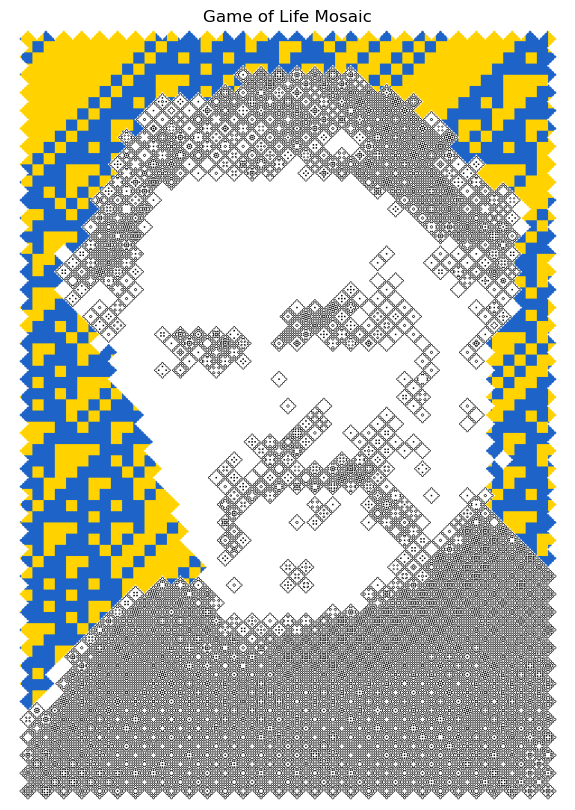

In [6]:
# Display mosaic
plt.figure(figsize=(10, 10))
plt.imshow(mosaic)
plt.title('Game of Life Mosaic')
plt.axis('off')
plt.show()

If you like, try creating a slightly different one (with a different background or different resolution) by returning to Step 3 and creating a generator object with different random settings.

## Step 5: Save the Result

Save the mosaic to a file, if you like.

In [7]:
# Set to True to save the mosaic to the output directory
SAVEFIG = False

# Save to output directory
if SAVEFIG:
    output_path = REPO / 'output/images/quickstart_mosaic.png'
    mosaic.save(output_path)
    print(f"Mosaic saved to: {output_path}")
else:
    print("Mosaic not saved. Set SAVEFIG = True to save the mosaic to the output directory.")

Mosaic not saved. Set SAVEFIG = True to save the mosaic to the output directory.


## That's it!

You've created your first Game of Life mosaic. The complete process was:

```python
from gol_mosaics import MosaicGenerator

generator = MosaicGenerator()
mosaic = generator.generate_from_image('input.png')
mosaic.save('output.png')
```

## Next Step

Get acquainted with the parameters in [`02_parameters.ipynb`](02_parameters.ipynb), which ends with a playground to try your own settings:
- Different `level` values (1-6 for diamonds, 3-5 for squares)
- Square tiles instead of diamonds (`layout='square'`)
- Different `grid_size` values (higher = more detail)
- Different threshold values for the alpha channel and the background cut-off
- Custom colours with `ColourScheme`
- Different ECA rules (30, 45, 54, 106, 110, etc.)

## Advanced

To watch your mosaic in a Game of Life simulator, and see a glider break the still life, go to [`04_golly_export.ipynb`](04_golly_export.ipynb). How the tiles themselves are made is in [`05_how_tiles_work.ipynb`](05_how_tiles_work.ipynb). And if you want to start doing some coding yourself, you may want to solve some open problems within this repository, a number of which are listed in the `open_problems.ipynb` Notebook. In case you want to know how the Tiles are created, consult the `tile_generation.ipynb` Notebook.

Enjoy!